In [1]:
import numpy as np  
import pandas as pd                
import seaborn as sns               
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("mydrone_Data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8127 entries, 0 to 8126
Data columns (total 52 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time(millisecond)                            8127 non-null   int64  
 1   datetime(utc)                                8127 non-null   object 
 2   latitude                                     8127 non-null   float64
 3   longitude                                    8127 non-null   float64
 4   height_above_takeoff(feet)                   8127 non-null   float64
 5   height_above_ground_at_drone_location(feet)  8127 non-null   float64
 6   ground_elevation_at_drone_location(feet)     8127 non-null   float64
 7   altitude_above_seaLevel(feet)                8127 non-null   float64
 8   height_sonar(feet)                           8127 non-null   int64  
 9   speed(mph)                                   8127 non-null   float64
 10  

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace("(", "_").str.replace(")", "")
print(df.columns)

Index(['time_millisecond', 'datetime_utc', 'latitude', 'longitude',
       'height_above_takeoff_feet',
       'height_above_ground_at_drone_location_feet',
       'ground_elevation_at_drone_location_feet',
       'altitude_above_sealevel_feet', 'height_sonar_feet', 'speed_mph',
       'distance_feet', 'mileage_feet', 'satellites', 'gpslevel', 'voltage_v',
       'max_altitude_feet', 'max_ascent_feet', 'max_speed_mph',
       'max_distance_feet', 'xspeed_mph', 'yspeed_mph', 'zspeed_mph',
       'compass_heading_degrees', 'pitch_degrees', 'roll_degrees', 'isphoto',
       'isvideo', 'rc_elevator', 'rc_aileron', 'rc_throttle', 'rc_rudder',
       'rc_elevator_percent', 'rc_aileron_percent', 'rc_throttle_percent',
       'rc_rudder_percent', 'gimbal_heading_degrees', 'gimbal_pitch_degrees',
       'gimbal_roll_degrees', 'battery_percent', 'voltagecell1',
       'voltagecell2', 'voltagecell3', 'voltagecell4', 'voltagecell5',
       'voltagecell6', 'current_a', 'battery_temperature_f', 'alt

In [4]:
dfy = df.drop(columns=["datetime_utc", "message"])


In [5]:
cols_voltage = dfy.columns[dfy.columns.str.startswith("voltage")]
dfx = dfy.drop(columns=cols_voltage)

In [6]:
dfxi = dfx[dfx["flycstate"] != 'P-GPS']

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X = dfxi.drop(columns=["flycstate"])
y = encoder.fit_transform(dfxi["flycstate"])

In [8]:
encoder.classes_

array(['AutoLanding', 'Sport', 'Waypoint'], dtype=object)

In [9]:
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(mapping)


{'AutoLanding': np.int64(0), 'Sport': np.int64(1), 'Waypoint': np.int64(2)}


In [10]:
inverse_mapping = dict(enumerate(encoder.classes_))
print(inverse_mapping)


{0: 'AutoLanding', 1: 'Sport', 2: 'Waypoint'}


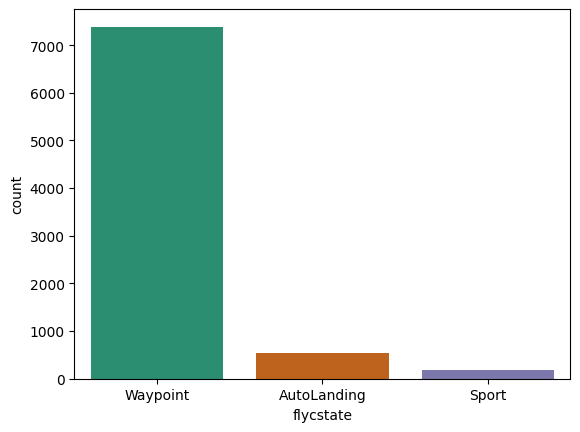

In [11]:
sns.countplot(x=dfxi["flycstate"], hue=dfxi["flycstate"], palette="Dark2")
plt.show()

In [12]:
dfx["flycstate"].value_counts()

flycstate
Waypoint       7387
AutoLanding     546
Sport           193
P-GPS             1
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                     y, 
                                                     test_size=0.2, 
                                                     stratify=y,
                                                     random_state=42)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6500, 42)
(1626, 42)
(6500,)
(1626,)


In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, KFold, StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score


estimators = XGBClassifier(objective="binary:logistic", random_state=42)

cv = KFold(random_state=42, n_splits=5, shuffle=True)

param_grid = {
              "learning_rate":[0.01, 0.1, 0.3],
              "max_depth":[3,5,7],
              "subsample": [0.6,0.8,1.0],
              "colsample_bytree":[0.6,0.8,1.0],
              "n_estimators":[100,200,300]
              }

grid_search = GridSearchCV(estimator=estimators,
                           param_grid=param_grid,
                           cv=cv,
                           verbose=2,
                           n_jobs=-1
                                    )
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [16]:
grid_search.best_estimator_

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

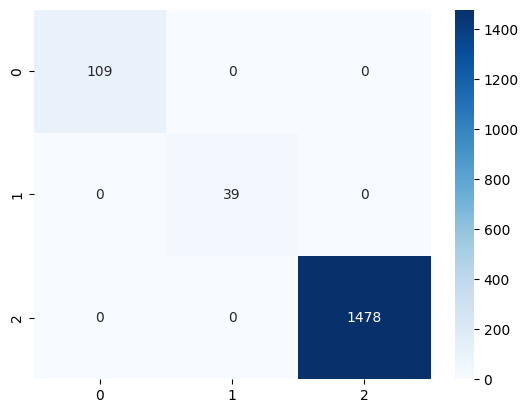

In [17]:
y_predict = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)


from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, y_predict)


sns.heatmap(data=conf_mat, annot=True, fmt="d", 
            cmap="Blues"
            )
plt.show()

In [18]:
y_proba.shape

(1626, 3)

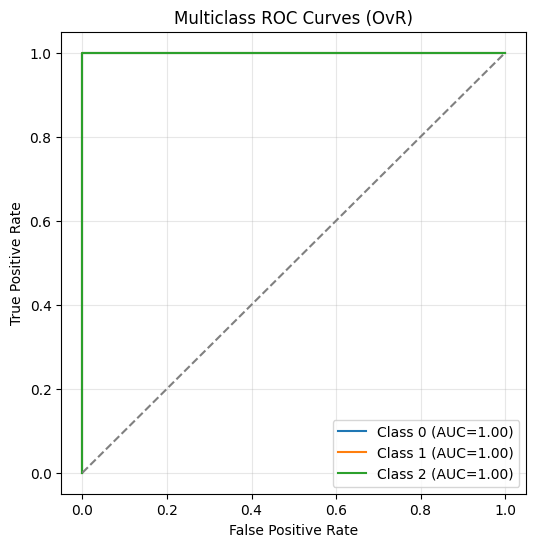

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(6, 6))

for class_id in range(y_proba.shape[1]):
    fpr, tpr, _ = roc_curve(
        (y_test == class_id).astype(int),
        y_proba[:, class_id]
    )
    auc = roc_auc_score(
        (y_test == class_id).astype(int),
        y_proba[:, class_id]
    )

    plt.plot(fpr, tpr, label=f"Class {class_id} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves (OvR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Probablities


In [34]:
import numpy as np           

prob_of_predicted_class = y_proba[np.arange(len(y_predict)), y_predict]

In [ ]:
# print(y_proba)
# how decision is made argmax(probabilities)
pd.DataFrame(y_proba, columns=["class0", "class1", "class2"])

,class0,class1,class2
0,0.093872,0.090200,0.815928
1,0.093872,0.090200,0.815928
2,0.093872,0.090200,0.815928
3,0.666994,0.112196,0.220810
4,0.093872,0.090200,0.815928
...,...,...,...
1621,0.093872,0.090200,0.815928
1622,0.122261,0.096575,0.781164
1623,0.093872,0.090200,0.815928
1624,0.093872,0.090200,0.815928


In [37]:
import pandas as pd

results = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_predict,
    "prob_predicted_class": prob_of_predicted_class
})

results.head()


,y_true,y_pred,prob_predicted_class
0,2,2,0.815928
1,2,2,0.815928
2,2,2,0.815928
3,0,0,0.666994
4,2,2,0.815928


In [41]:
# grid_search.fit(X_train, y_train)

import shap

explainer = shap.Explainer(grid_search.best_estimator_)
shap_values = explainer(X_test)

In [46]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

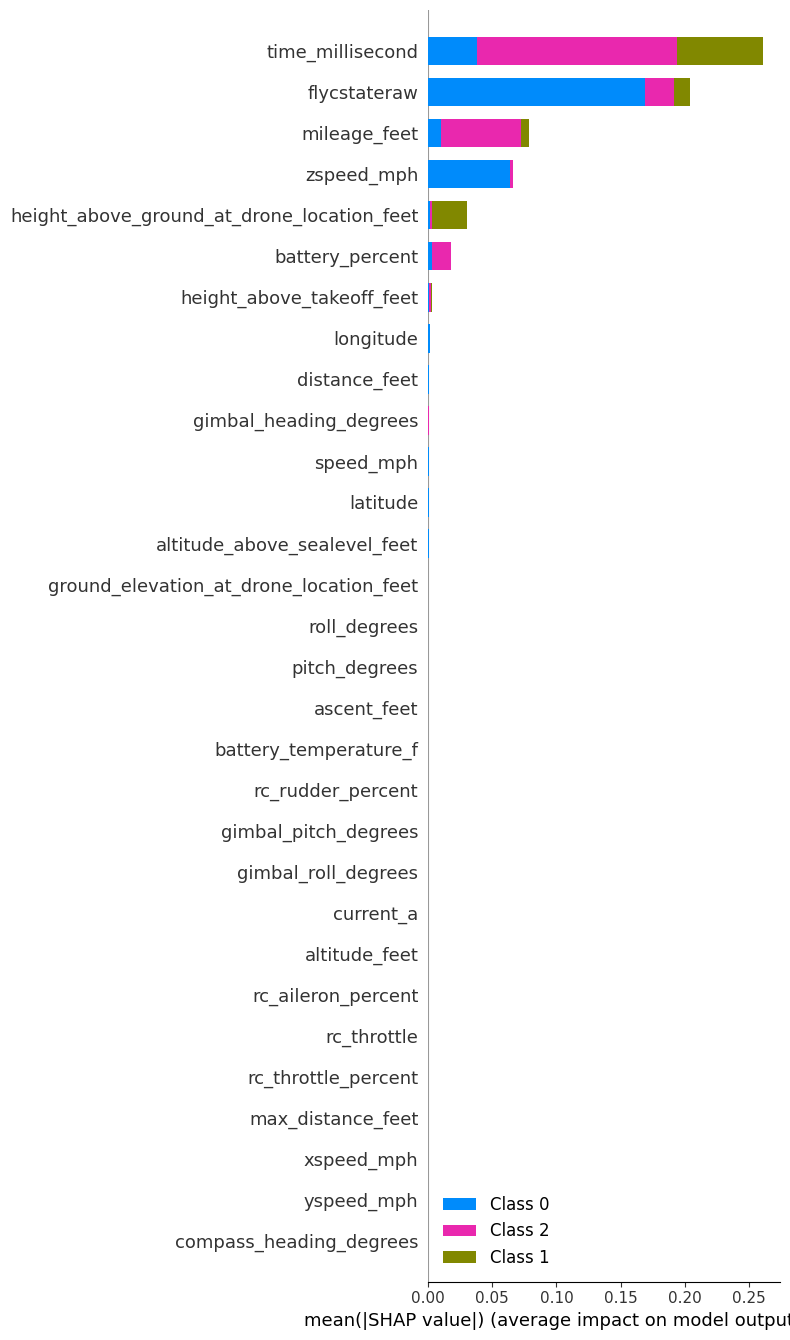

In [52]:
# plt.figure(figsize=(10,15))
shap.summary_plot(shap_values, 
                  X_test_df, 
                  plot_type="bar",
                  max_display=30)